# NYC Airbnb Dataset

In [420]:
import pandas as pd 
import seaborn as sns
import plotly.express as px

In [421]:
df = pd.read_csv(r'C:\Users\karan.chawla\Desktop\AB_NYC_2019.csv')

In [422]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='str')

In [423]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [424]:
df.shape

(48895, 16)

In [425]:
df.isnull().sum()

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

In [426]:
df.nunique()

id                                48895
name                              47905
host_id                           37457
host_name                         11452
neighbourhood_group                   5
neighbourhood                       221
latitude                          19048
longitude                         14718
room_type                             3
price                               674
minimum_nights                      109
number_of_reviews                   394
last_review                        1764
reviews_per_month                   937
calculated_host_listings_count       47
availability_365                    366
dtype: int64

## Q. What factors are affecting the price of an Airbnb in NYC (& How) ?
### Let's take Neighbourhoods and different room types into account

In [427]:
#Let's drop columns that I think aren't needed at all
df = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'latitude', 'longitude'])

In [428]:
df.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365
1,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,Manhattan,Harlem,Private room,150,3,0,NaN,NaN,1,365
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,Manhattan,East Harlem,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


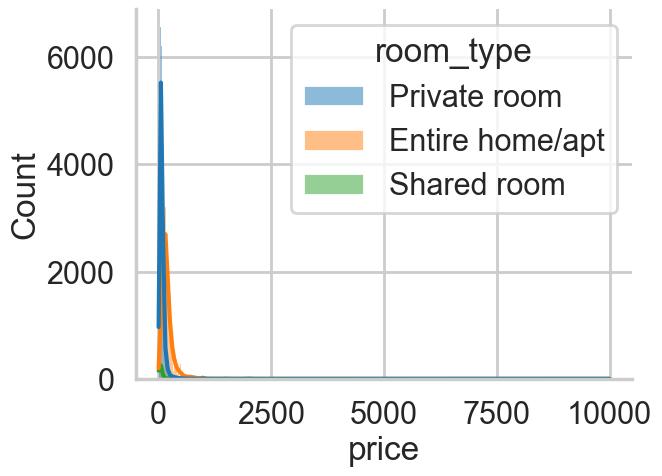

In [489]:
sns.set_style('whitegrid')
sns.set_context('poster')
sns.histplot(x=df['price'], hue=df['room_type'], kde=True)
sns.despine()

<Axes: xlabel='price'>

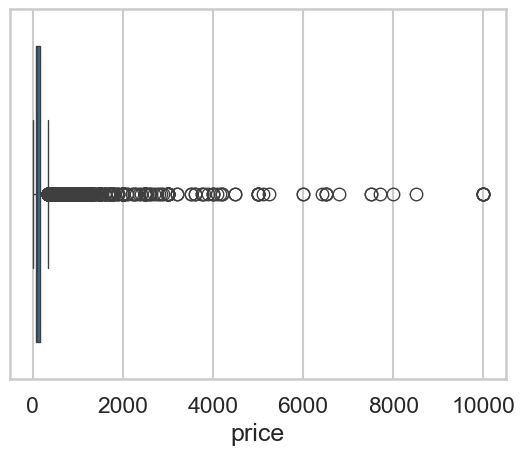

In [430]:
sns.boxplot(x=df['price'])

Should I remove the outliers? <br>
Maybe not because some properties might be listed for a super high price for their luxurious qualities or something

In [431]:
df['price'].describe()

count    48895.000000
mean       152.720687
std        240.154170
min          0.000000
25%         69.000000
50%        106.000000
75%        175.000000
max      10000.000000
Name: price, dtype: float64

C:\Users\karan.chawla\AppData\Local\Temp\ipykernel_8660\1747254639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['room_type'], palette='Accent')


<Axes: xlabel='room_type', ylabel='count'>

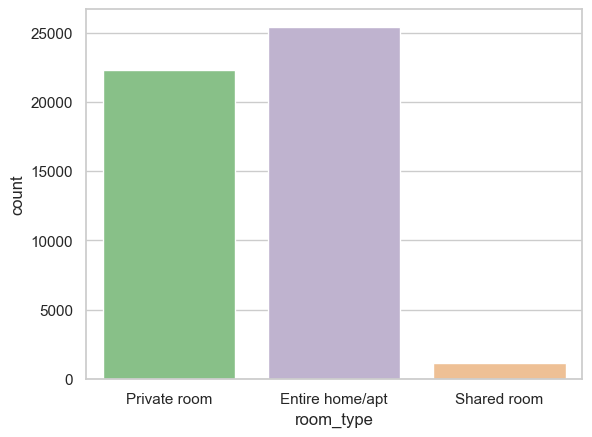

In [459]:
sns.set_context('notebook')
sns.countplot(x=df['room_type'], palette='Accent')

C:\Users\karan.chawla\AppData\Local\Temp\ipykernel_8660\2318529730.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['neighbourhood_group'], stat='percent', palette='CMRmap')


<Axes: xlabel='neighbourhood_group', ylabel='percent'>

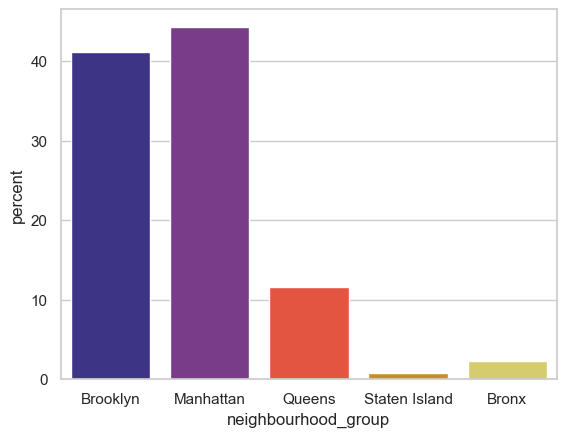

In [460]:
sns.set_context('notebook')
sns.countplot(x=df['neighbourhood_group'], stat='percent', palette='CMRmap')

I want to find the median of each Room type, in each area of NYC, so I'll use the groupby function

In [434]:
group1 = df.groupby('room_type')
room_price_df = group1['price'].median()
room_price_df

room_type
Entire home/apt    160.0
Private room        70.0
Shared room         45.0
Name: price, dtype: float64

In [435]:
group2 = df.groupby('neighbourhood_group')
neighbourhood_price_df = group2['price'].median()
neighbourhood_price_df

neighbourhood_group
Bronx             65.0
Brooklyn          90.0
Manhattan        150.0
Queens            75.0
Staten Island     75.0
Name: price, dtype: float64

What I did above is not sufficient, hence I will need to group both the above together and find the mean of that

In [436]:
group3 = df.groupby(['neighbourhood_group', 'room_type'])
neighbourhood_room_price = group3['price'].transform('median')

In [437]:
#adding it to the df
df['grouped median'] = neighbourhood_room_price
df.tail()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,grouped median
48890,Brooklyn,Bedford-Stuyvesant,Private room,70,2,0,NaN,NaN,2,9,65.0
48891,Brooklyn,Bushwick,Private room,40,4,0,NaN,NaN,2,36,65.0
48892,Manhattan,Harlem,Entire home/apt,115,10,0,NaN,NaN,1,27,191.0
48893,Manhattan,Hell's Kitchen,Shared room,55,1,0,NaN,NaN,6,2,69.0
48894,Manhattan,Hell's Kitchen,Private room,90,7,0,NaN,NaN,1,23,90.0


Now, I'll make another column that will compare the price of the listing to its grouped median

In [438]:
df['price ratio'] = df['price']/df['grouped median']
df['price ratio'].describe()

count    48895.000000
mean         1.255239
std          1.926297
min          0.000000
25%          0.755556
50%          1.000000
75%          1.319372
max        166.666667
Name: price ratio, dtype: float64

Why is the minimum ratio 0? I guess some listings price is mentioned as 0. Let's check

In [439]:
df[df['price']==0]

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,grouped median,price ratio
23161,Brooklyn,Bedford-Stuyvesant,Private room,0,4,1,2018-01-06,0.05,4,28,65.0,0.0
25433,Bronx,East Morrisania,Private room,0,2,55,2019-06-24,2.56,4,127,53.5,0.0
25634,Brooklyn,Bushwick,Private room,0,2,16,2019-05-18,0.71,5,0,65.0,0.0
25753,Brooklyn,Greenpoint,Private room,0,2,12,2017-10-27,0.53,2,0,65.0,0.0
25778,Brooklyn,Williamsburg,Entire home/apt,0,5,3,2018-01-02,0.15,1,73,145.0,0.0
25794,Brooklyn,Bedford-Stuyvesant,Private room,0,1,93,2019-06-15,4.28,6,176,65.0,0.0
25795,Brooklyn,Bedford-Stuyvesant,Private room,0,1,95,2019-06-21,4.37,6,232,65.0,0.0
25796,Brooklyn,Bedford-Stuyvesant,Private room,0,1,95,2019-06-23,4.35,6,222,65.0,0.0
26259,Manhattan,Murray Hill,Entire home/apt,0,3,0,NaN,NaN,1,0,191.0,0.0
26841,Brooklyn,Bushwick,Shared room,0,30,2,2019-06-22,0.11,6,333,36.0,0.0


In [440]:
#removing the above values
df = df[df["price"] > 0]

#let's compute the median and ratios again
neighbourhood_room_price = group3['price'].transform('median')
df['grouped median'] = neighbourhood_room_price
df['price ratio'] = df['price']/df['grouped median']
df['price ratio'].describe()

count    48884.000000
mean         1.255522
std          1.926422
min          0.052356
25%          0.755556
50%          1.000000
75%          1.322222
max        166.666667
Name: price ratio, dtype: float64

In [441]:
Q25 = df['price ratio'].quantile(0.25) #0.7555
Q75 = df['price ratio'].quantile(0.75) #1.3222

In [442]:
def classify_listing(x):
    if x>=Q25 and x<=Q75:
        return "Fair"
    elif x<=2.0 and x>Q75:
        return "Slightly Overpriced"
    elif x>2.0:
        return "Overpriced"
    else:
        return "Underpriced"

df['Worth'] = df['price ratio'].apply(classify_listing)
df.head()

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,grouped median,price ratio,Worth
0,Brooklyn,Kensington,Private room,149,1,9,2018-10-19,0.21,6,365,65.0,2.292308,Overpriced
1,Manhattan,Midtown,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,191.0,1.178010,Fair
2,Manhattan,Harlem,Private room,150,3,0,NaN,NaN,1,365,90.0,1.666667,Slightly Overpriced
3,Brooklyn,Clinton Hill,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,145.0,0.613793,Underpriced
4,Manhattan,East Harlem,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,191.0,0.418848,Underpriced


In [443]:
df['Worth'].value_counts(normalize=True)

Worth
Fair                   0.501493
Underpriced            0.249366
Slightly Overpriced    0.162753
Overpriced             0.086388
Name: proportion, dtype: float64

<Axes: xlabel='room_type', ylabel='probability'>

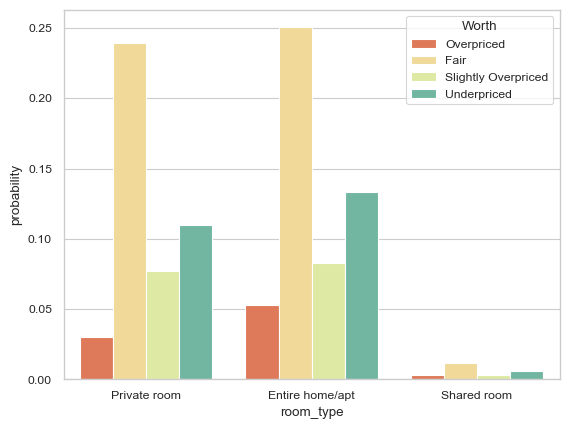

In [479]:
#What room type has a higher chance of being overpriced?
sns.set_context('paper')
sns.countplot(x=df['room_type'], hue=df['Worth'], stat='probability', palette='Spectral')

### <b>Observation</b><br>
Entire homes/apt show the highest variability in pricing, with both higher probabilities of being overpriced and underpriced compared to other room types. This suggests less standardized pricing and greater flexibility in how hosts price entire properties.

<Axes: xlabel='neighbourhood_group', ylabel='probability'>

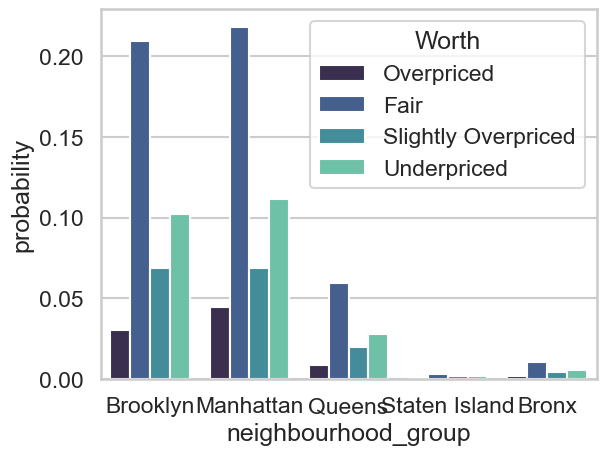

In [472]:
sns.countplot(x=df['neighbourhood_group'], hue=df['Worth'], stat='probability', palette='mako')

Major markets (Manhattan, Brooklyn) are less efficiently priced, offering both overpriced listings and potential undervalued listings.

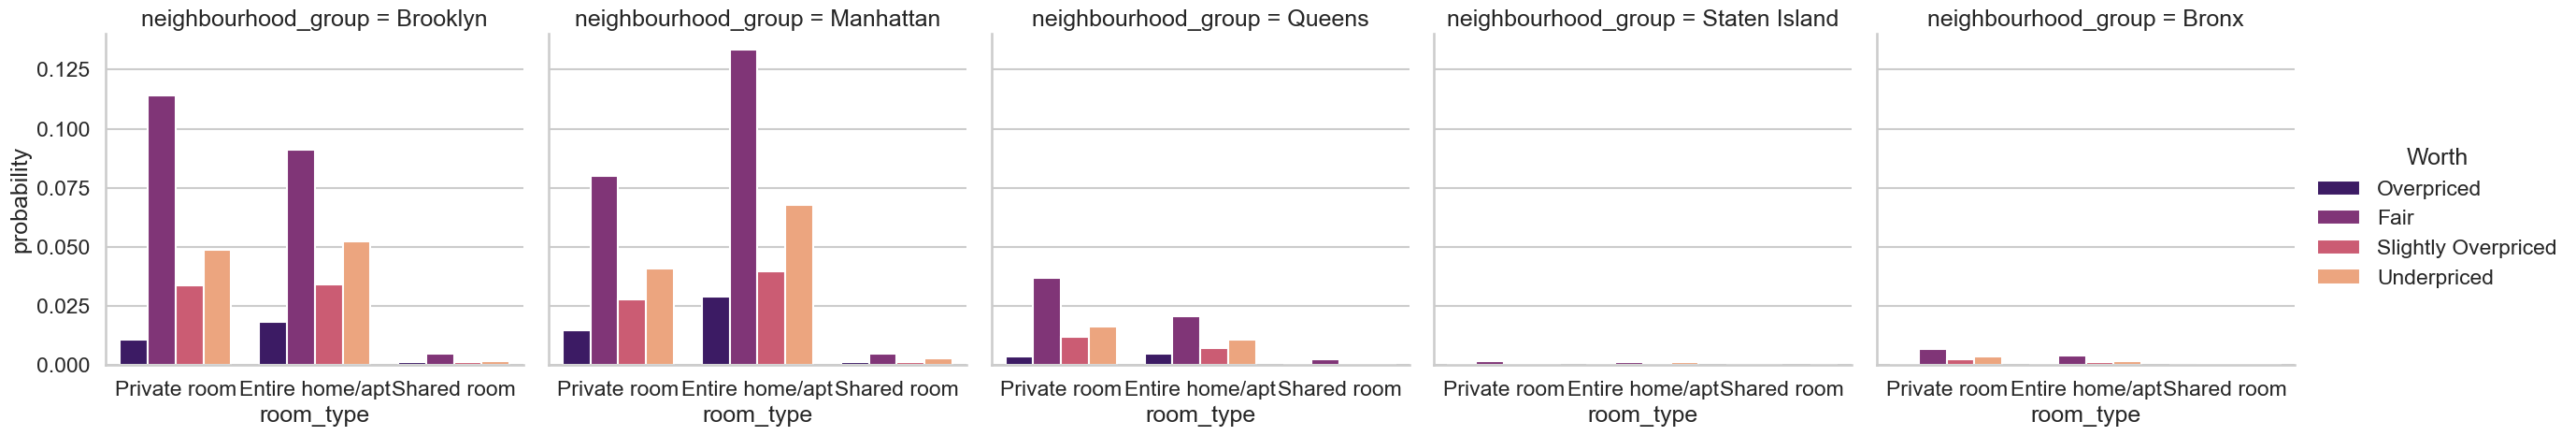

In [474]:
sns.catplot(
    data=df,
    x="room_type",
    hue="Worth",
    col="neighbourhood_group",
    kind='count',
    stat="probability",
    palette='magma'
)

## <b>Main Insight</b><br>
Basically, Manhattan is NYC's most expensive and posh area. It's location affects the price of listings the most compared to any other neighbourhood. Ofcourse, entire homes or apartments will be expensive due to it's privacy, size, amenities, etc compared to a private or shared room. <br>
BUT <br>
Entire homes/apt in Manhattan have the most inconsistent pricing. Some are way more expensive than they should be, while others are cheaper than expected. This means prices in this segment aren’t very standardized (compared to the market), so you might overpay or get a great deal instead.

<Axes: xlabel='room_type', ylabel='price'>

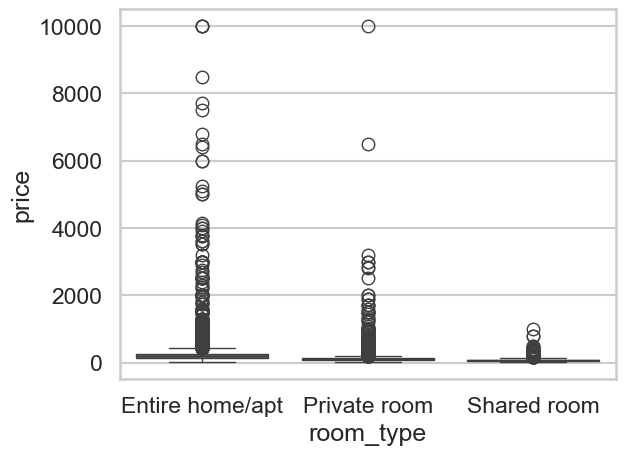

In [447]:
sns.set_context('talk')
df_manhattan = df[df['neighbourhood_group']=='Manhattan']
sns.boxplot(x=df_manhattan['room_type'], y=df_manhattan['price'])

The ‘Entire home/apt’ category in Manhattan has the largest IQR, indicating the highest variability in prices. This proves my above insight that listings range widely from relatively affordable to very expensive, showing that pricing in this segment is highly inconsistent.

In [448]:
df_manhattan_homes = df_manhattan[df_manhattan['room_type'] =='Entire home/apt']
df_manhattan_homes.describe()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,grouped median,price ratio
count,13198.000000,13198.000000,13198.000000,9967.000000,13198.000000,13198.000000,13198.0,13198.000000
mean,249.257994,10.539855,17.816866,1.141610,18.924079,117.149871,191.0,1.305016
std,331.835611,26.494686,36.680082,1.426206,60.242014,134.283426,0.0,1.737359
min,10.000000,1.000000,0.000000,0.010000,1.000000,0.000000,191.0,0.052356
25%,143.000000,2.000000,1.000000,0.160000,1.000000,0.000000,191.0,0.748691
50%,191.000000,3.000000,4.000000,0.530000,1.000000,42.000000,191.0,1.000000
75%,259.000000,7.000000,16.000000,1.630000,2.000000,245.000000,191.0,1.356021
max,10000.000000,1250.000000,447.000000,14.000000,327.000000,365.000000,191.0,52.356021


In [449]:
df_manhattan_homes[df_manhattan_homes['price']==10]

,neighbourhood_group,neighbourhood,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,grouped median,price ratio,Worth
2860,Manhattan,East Village,Entire home/apt,10,30,0,NaN,NaN,4,137,191.0,0.052356,Underpriced
23256,Manhattan,Upper East Side,Entire home/apt,10,3,10,2018-10-22,0.39,1,0,191.0,0.052356,Underpriced


An entire home in Manhattan can range from anywhere between $10 to $10,000. But these are just extreme values, (as shown above, only 2) not the typical ones, yet both (extreme and typical) show the greatest price variability amongst all room types.

C:\Users\karan.chawla\AppData\Local\Temp\ipykernel_8660\1074989157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=df['Worth'], y=df['number_of_reviews'], palette='Set2')


<Axes: xlabel='Worth', ylabel='number_of_reviews'>

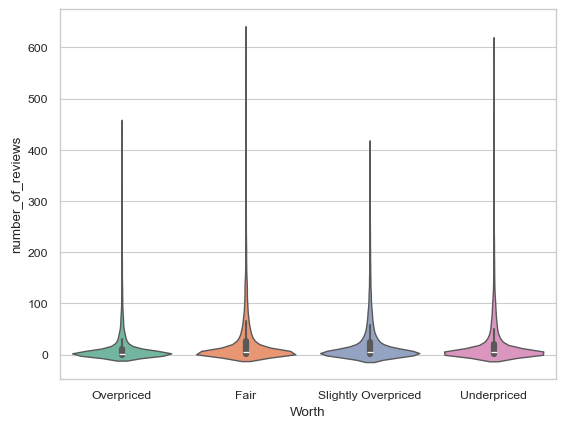

In [450]:
sns.set_context('paper')
sns.violinplot(x=df['Worth'], y=df['number_of_reviews'], palette='Set2')

### <b>Insight</b><br>
Overpriced listings tend to receive fewer reviews compared to fairly priced or underpriced listings, suggesting that higher prices negatively impact demand.